# Session 1 Playground — MAPID Custom Polygons

Load polygon data from local sample file, **validate** with Shapely, **correct** fixable geometries, and compare **before vs after** with tables and maps (matplotlib + Folium).

**Sample data:** 50 polygons — 16 valid, 20 self-intersection/sliver (fixable), 14 overlap review. Regenerate with `python scripts/generate_mapid_polygons.py`.

**Tracks:**
- **Core** — all mentees
- **Extend** — mid mentees (marked below)

## Setup

In [ ]:
import json
import math
from pathlib import Path

import folium
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.validation import explain_validity

SESSION_DIR = Path(".").resolve()
DATA_DIR = SESSION_DIR / "data"
OUTPUT_DIR = SESSION_DIR / "output"
DATA_FILE = DATA_DIR / "mapid-polygons.json"
TARGET_CRS = "EPSG:4326"
AREA_THRESHOLD_HA = 5

COLOR_VALID = "#4C78A8"
COLOR_INVALID = "#E45756"
COLOR_FIXED = "#54A24B"
COLOR_OVERLAP = "#F58518"


def validity_reason(geom) -> str:
    if geom is None or geom.is_empty:
        return "Empty geometry"
    return "Valid" if geom.is_valid else explain_validity(geom)


def is_overlap_review(row: pd.Series) -> bool:
    return "overlap" in str(row.get("qa_flag", ""))


def plot_gdf_subset(ax, subset, color, edgecolor="black", alpha=0.7, linewidth=0.5, **kwargs):
    if subset.empty:
        return
    subset.plot(ax=ax, color=color, edgecolor=edgecolor, alpha=alpha, linewidth=linewidth, **kwargs)


## 1. Load data

Read the local GeoJSON FeatureCollection — no API key required.

In [17]:
with DATA_FILE.open(encoding="utf-8") as f:
    data = json.load(f)

print(f"Loaded: {DATA_FILE}")
print(f"Response keys: {list(data.keys())}")
print(f"Total features: {len(data.get('features', []))}")


Loaded: /Users/raden/mapid-python/session-1/data/mapid-polygons.json
Response keys: ['type', 'total', 'features', 'metadata']
Total features: 50


In [27]:
features = data["features"]
gdf = gpd.GeoDataFrame.from_features(features, crs="EPSG:4326")

print(f"Rows: {len(gdf)}")
print(f"CRS: {gdf.crs}")
print(f"Geometry types: {gdf.geometry.geom_type.unique()}")
gdf.head()


Rows: 50
CRS: EPSG:4326
Geometry types: ['Polygon']


,geometry,id,name,category,qa_flag,fixable,fix_method,invalid_severity,expected_mapid_upload,overlap_with,overlap_pct,instructor_note
0,"POLYGON ((106.78026 -6.32006, 106.78826 -6.320...",poly-001,Zone 01,industrial,none,False,none,None,True,None,NaN,Valid geometry — no correction needed
1,"POLYGON ((106.81117 -6.31858, 106.81917 -6.318...",poly-002,Zone 02,green,none,False,none,None,True,None,NaN,Valid geometry — no correction needed
2,"POLYGON ((106.84758 -6.31517, 106.85558 -6.315...",poly-003,Zone 03,residential,none,False,none,None,True,None,NaN,Valid geometry — no correction needed
3,"POLYGON ((106.88195 -6.3196, 106.88995 -6.3196...",poly-004,Zone 04,green,none,False,none,None,True,None,NaN,Valid geometry — no correction needed
4,"POLYGON ((106.91215 -6.32003, 106.92015 -6.320...",poly-005,Zone 05,commercial,none,False,none,None,True,None,NaN,Valid geometry — no correction needed


## 2. Validate (Shapely)

Detect invalid polygons and inspect QA metadata.

In [28]:
gdf_before = gdf.copy()
gdf_before["geometry_valid_before"] = gdf_before.geometry.is_valid
gdf_before["validity_reason_before"] = gdf_before.geometry.apply(validity_reason)
gdf_before["geometry_original"] = gdf_before.geometry.copy()

gdf["geometry_valid"] = gdf.geometry.is_valid
gdf["overlap_review"] = gdf.apply(is_overlap_review, axis=1)

print(f"Geometry valid: {gdf['geometry_valid'].sum()} / {len(gdf)}")
print(f"Valid baseline (qa_flag=none): {(gdf['qa_flag'] == 'none').sum()}")
print(f"Self-intersection/sliver (fixable): {gdf['fixable'].sum()}")
print(f"Overlap review: {gdf['overlap_review'].sum()}")


Geometry valid: 34 / 50
Valid baseline (qa_flag=none): 16
Self-intersection/sliver (fixable): 20
Overlap review: 14


In [29]:
invalid_rows = gdf.loc[~gdf["geometry_valid"], ["id", "qa_flag", "fixable", "invalid_severity"]]
print("Invalid geometry IDs:")
print(invalid_rows)

print("\nValidity reasons (invalid only):")
for _, row in gdf.loc[~gdf["geometry_valid"]].iterrows():
    print(f"  {row['id']}: {validity_reason(row.geometry)}")


Invalid geometry IDs:
          id            qa_flag  fixable invalid_severity
16  poly-017  self_intersection     True           severe
17  poly-018  self_intersection     True           severe
18  poly-019             sliver     True           severe
19  poly-020  self_intersection     True           severe
20  poly-021  self_intersection     True           severe
21  poly-022             sliver     True           severe
22  poly-023  self_intersection     True           severe
23  poly-024  self_intersection     True           severe
24  poly-025             sliver     True           severe
25  poly-026  self_intersection     True           severe
26  poly-027  self_intersection     True           severe
27  poly-028             sliver     True           severe
29  poly-030  self_intersection     True             mild
31  poly-032  self_intersection     True             mild
33  poly-034  self_intersection     True             mild
35  poly-036  self_intersection     True          

## 3. Correct fixable only

Apply `buffer(0)` only on rows that are invalid **and** marked fixable. Overlap cases are left for manual review.

In [30]:
invalid_before = (~gdf["geometry_valid"]).sum()
fix_mask = (~gdf["geometry_valid"]) & (gdf["fixable"] == True)
gdf.loc[fix_mask, "geometry"] = gdf.loc[fix_mask, "geometry"].buffer(0)

gdf["geometry_valid"] = gdf.geometry.is_valid
gdf["fix_applied"] = fix_mask
gdf["validity_reason_after"] = gdf.geometry.apply(validity_reason)

print(f"Invalid before fix: {invalid_before}")
print(f"Fixed with buffer(0): {fix_mask.sum()}")
print(f"Valid after fix: {gdf['geometry_valid'].sum()} / {len(gdf)}")
print(f"Overlap rows still need manual review: {gdf['overlap_review'].sum()}")


Invalid before fix: 16
Fixed with buffer(0): 16
Valid after fix: 50 / 50
Overlap rows still need manual review: 14


## 4. Before vs after comparison

In [31]:
report = pd.DataFrame({
    "id": gdf_before["id"],
    "name": gdf_before["name"],
    "qa_flag": gdf_before["qa_flag"],
    "geometry_valid_before": gdf_before["geometry_valid_before"],
    "geometry_valid_after": gdf["geometry_valid"].values,
    "validity_reason_before": gdf_before["validity_reason_before"],
    "validity_reason_after": gdf["validity_reason_after"].values,
    "fix_applied": gdf["fix_applied"].values,
    "overlap_review": gdf["overlap_review"].values,
})


def status_change(row):
    if row["overlap_review"]:
        return "overlap_review"
    if row["geometry_valid_before"] and row["geometry_valid_after"]:
        return "valid→valid"
    if not row["geometry_valid_before"] and row["geometry_valid_after"]:
        return "invalid→valid"
    if not row["geometry_valid_before"] and not row["geometry_valid_after"]:
        return "invalid→invalid"
    return "valid→invalid"


report["status_change"] = report.apply(status_change, axis=1)

valid_before = report["geometry_valid_before"].sum()
invalid_before = (~report["geometry_valid_before"]).sum()
overlap_review = report["overlap_review"].sum()
fixed_count = report["fix_applied"].sum()
valid_after = report["geometry_valid_after"].sum()
still_invalid = (~report["geometry_valid_after"]).sum()

print("=== Validation summary ===")
print(f"BEFORE:  valid={valid_before}  invalid={invalid_before}  overlap_review={overlap_review}")
print(f"FIXED:   buffer(0) applied to {fixed_count} polygons")
print(f"AFTER:   valid={valid_after}  still_invalid={still_invalid}  overlap_review={overlap_review} (unchanged, needs human)")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
report.to_csv(OUTPUT_DIR / "comparison_report.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'comparison_report.csv'}")
report


=== Validation summary ===
BEFORE:  valid=34  invalid=16  overlap_review=14
FIXED:   buffer(0) applied to 16 polygons
AFTER:   valid=50  still_invalid=0  overlap_review=14 (unchanged, needs human)

Saved: /Users/raden/mapid-python/session-1/output/comparison_report.csv


,id,name,qa_flag,geometry_valid_before,geometry_valid_after,validity_reason_before,validity_reason_after,fix_applied,overlap_review,status_change
0,poly-001,Zone 01,none,True,True,Valid,Valid,False,False,valid→valid
1,poly-002,Zone 02,none,True,True,Valid,Valid,False,False,valid→valid
2,poly-003,Zone 03,none,True,True,Valid,Valid,False,False,valid→valid
3,poly-004,Zone 04,none,True,True,Valid,Valid,False,False,valid→valid
4,poly-005,Zone 05,none,True,True,Valid,Valid,False,False,valid→valid
5,poly-006,Zone 06,none,True,True,Valid,Valid,False,False,valid→valid
6,poly-007,Zone 07,none,True,True,Valid,Valid,False,False,valid→valid
7,poly-008,Zone 08,none,True,True,Valid,Valid,False,False,valid→valid
8,poly-009,Zone 09,none,True,True,Valid,Valid,False,False,valid→valid
9,poly-010,Zone 10,none,True,True,Valid,Valid,False,False,valid→valid


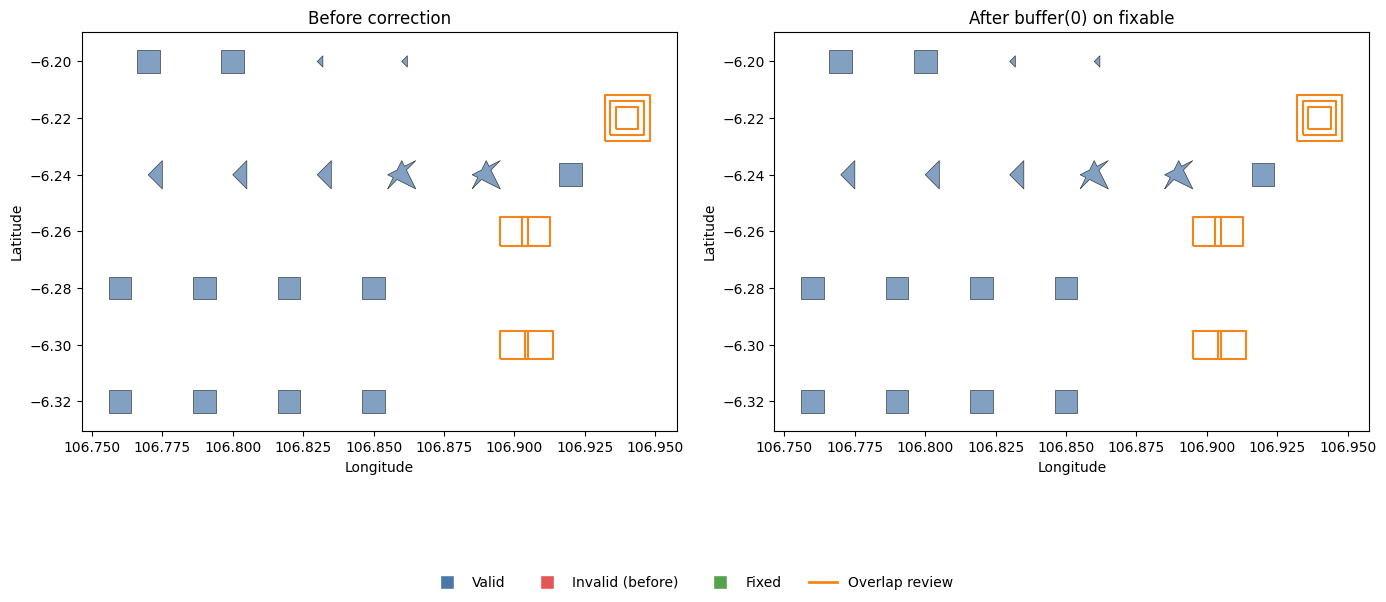

In [21]:
overlap_before = gdf_before[gdf_before.apply(is_overlap_review, axis=1)]
invalid_before_gdf = gdf_before[~gdf_before["geometry_valid_before"]]
valid_before_gdf = gdf_before[gdf_before["geometry_valid_before"] & ~gdf_before.apply(is_overlap_review, axis=1)]

fixed_after = gdf[gdf["fix_applied"]]
overlap_after = gdf[gdf["overlap_review"]]
valid_after_gdf = gdf[gdf["geometry_valid"] & ~gdf["fix_applied"] & ~gdf["overlap_review"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_gdf_subset(axes[0], valid_before_gdf, COLOR_VALID)
plot_gdf_subset(axes[0], invalid_before_gdf, COLOR_INVALID)
if not overlap_before.empty:
    overlap_before.plot(ax=axes[0], facecolor="none", edgecolor=COLOR_OVERLAP, linewidth=1.5)

axes[0].set_title("Before correction")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

plot_gdf_subset(axes[1], valid_after_gdf, COLOR_VALID)
plot_gdf_subset(axes[1], fixed_after, COLOR_FIXED)
if not overlap_after.empty:
    overlap_after.plot(ax=axes[1], facecolor="none", edgecolor=COLOR_OVERLAP, linewidth=1.5)

axes[1].set_title("After buffer(0) on fixable")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")

legend_handles = [
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=COLOR_VALID, markersize=10, label="Valid"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=COLOR_INVALID, markersize=10, label="Invalid (before)"),
    plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=COLOR_FIXED, markersize=10, label="Fixed"),
    plt.Line2D([0], [0], color=COLOR_OVERLAP, linewidth=2, label="Overlap review"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
fig.savefig(OUTPUT_DIR / "before_after_map.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
fixed_ids = report.loc[report["fix_applied"], "id"].tolist()

if fixed_ids:
    n = len(fixed_ids)
    cols = min(3, n)
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes_list = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, poly_id in zip(axes_list, fixed_ids):
        before_row = gdf_before[gdf_before["id"] == poly_id].iloc[0]
        after_row = gdf[gdf["id"] == poly_id].iloc[0]
        reason_before = before_row["validity_reason_before"]

        gpd.GeoSeries([before_row["geometry_original"]], crs=gdf_before.crs).plot(
            ax=ax, facecolor="none", edgecolor=COLOR_INVALID, linewidth=1.5, linestyle="--"
        )
        gpd.GeoSeries([after_row.geometry], crs=gdf.crs).plot(
            ax=ax, color=COLOR_FIXED, edgecolor="black", alpha=0.5, linewidth=0.8
        )
        ax.set_title(f"{poly_id}\n{reason_before} → Valid", fontsize=9)
        ax.set_axis_off()

    for ax in axes_list[n:]:
        ax.set_axis_off()

    fig.suptitle("Fixed polygons — original (red dashed) vs corrected (green)", fontsize=12)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "fixed_polygons_detail.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No fixed polygons to show.")


No fixed polygons to show.


## 5. Area and analysis

In [10]:
gdf_proj = gdf.to_crs(TARGET_CRS)
gdf["area_ha"] = gdf_proj.geometry.area / 10_000

centroids = gdf_proj.geometry.centroid.to_crs(4326)
gdf["centroid_lat"] = centroids.y
gdf["centroid_lon"] = centroids.x

gdf[["id", "name", "category", "area_ha", "geometry_valid"]].describe()


/var/folders/yf/crphcvwj3cg46rpjzbfd_scr0000gn/T/ipykernel_3523/547943652.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_ha"] = gdf_proj.geometry.area / 10_000
/var/folders/yf/crphcvwj3cg46rpjzbfd_scr0000gn/T/ipykernel_3523/547943652.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = gdf_proj.geometry.centroid.to_crs(4326)


,area_ha
count,2.500000e+01
mean,6.924000e-09
std,5.028111e-09
min,4.000000e-10
25%,4.000000e-09
50%,6.400000e-09
75%,6.400000e-09
max,2.560000e-08


In [11]:
large = gdf[gdf["area_ha"] > AREA_THRESHOLD_HA]
print(f"Polygons > {AREA_THRESHOLD_HA} ha: {len(large)}")
large[["name", "category", "area_ha"]]

summary = gdf.groupby("category")["area_ha"].agg(["count", "sum", "mean"]).round(2)
print("\nSummary by category:")
summary


Polygons > 5 ha: 0

Summary by category:


,count,sum,mean
category,,,
commercial,9,0.0,0.0
green,5,0.0,0.0
industrial,2,0.0,0.0
mixed,2,0.0,0.0
residential,7,0.0,0.0


## 6. Visualization — matplotlib + Folium

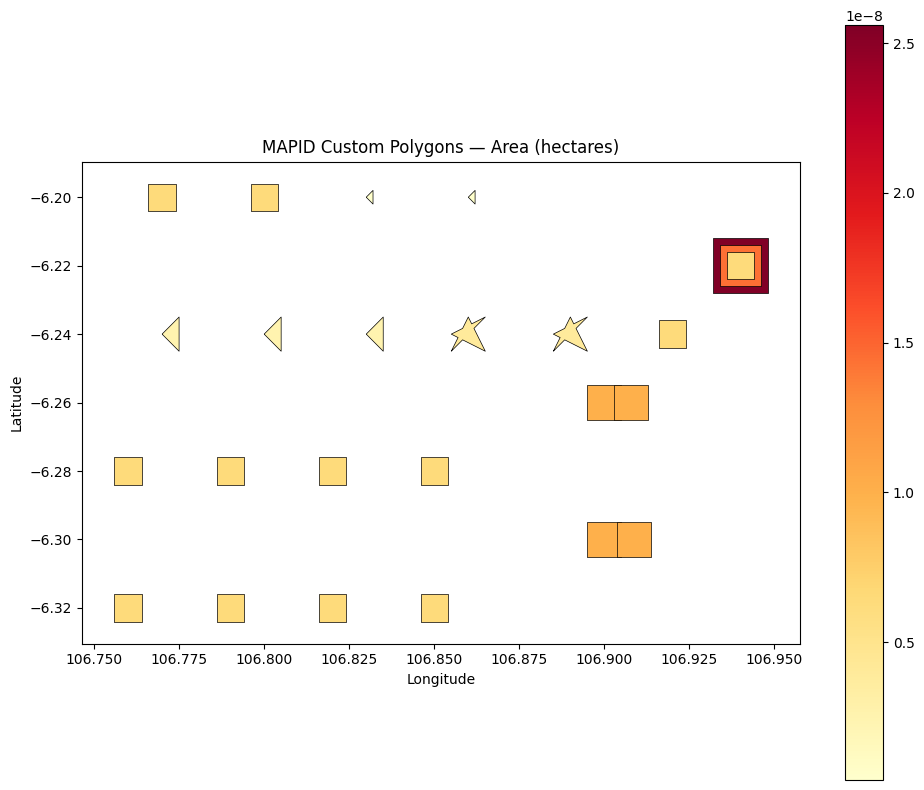

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
gdf.plot(column="area_ha", legend=True, ax=ax, cmap="YlOrRd", edgecolor="black", linewidth=0.5)
ax.set_title("MAPID Custom Polygons — Area (hectares)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "choropleth_area_ha.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
center_lat = gdf["centroid_lat"].mean()
center_lon = gdf["centroid_lon"].mean()

tooltip_fields = ["name", "category", "area_ha", "geometry_valid", "qa_flag", "status_change"]
gdf_map = gdf.copy()
gdf_map["status_change"] = report["status_change"].values


def folium_style(feature):
    props = feature.get("properties", {})
    if props.get("fix_applied"):
        return {"fillColor": COLOR_FIXED, "color": "black", "weight": 1, "fillOpacity": 0.6}
    if props.get("overlap_review"):
        return {"fillColor": "#ffffff", "color": COLOR_OVERLAP, "weight": 2, "fillOpacity": 0.1}
    if props.get("geometry_valid"):
        return {"fillColor": COLOR_VALID, "color": "black", "weight": 1, "fillOpacity": 0.6}
    return {"fillColor": COLOR_INVALID, "color": "black", "weight": 1, "fillOpacity": 0.6}


m_final = folium.Map(location=[center_lat, center_lon], zoom_start=11)
folium.GeoJson(
    gdf_map[tooltip_fields + ["geometry"]],
    name="Corrected polygons",
    style_function=folium_style,
    tooltip=folium.GeoJsonTooltip(fields=tooltip_fields),
).add_to(m_final)
folium.LayerControl().add_to(m_final)
m_final.save(str(OUTPUT_DIR / "map_final.html"))
m_final


In [25]:
m_compare = folium.Map(location=[center_lat, center_lon], zoom_start=11)

before_layer = folium.FeatureGroup(name="Before — invalid (red)", show=True)
for _, row in gdf_before[~gdf_before["geometry_valid_before"]].iterrows():
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda x: {"color": COLOR_INVALID, "weight": 2, "fillOpacity": 0.4},
        tooltip=f"{row['id']}: {row['validity_reason_before']}",
    ).add_to(before_layer)
before_layer.add_to(m_compare)

fixed_layer = folium.FeatureGroup(name="After — fixed (green)", show=True)
for _, row in gdf[gdf["fix_applied"]].iterrows():
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda x: {"color": COLOR_FIXED, "weight": 2, "fillOpacity": 0.5},
        tooltip=f"{row['id']}: Valid after buffer(0)",
    ).add_to(fixed_layer)
fixed_layer.add_to(m_compare)

overlap_layer = folium.FeatureGroup(name="Overlap review (orange)", show=True)
for _, row in gdf[gdf["overlap_review"]].iterrows():
    folium.GeoJson(
        row.geometry.__geo_interface__,
        style_function=lambda x: {"color": COLOR_OVERLAP, "weight": 2, "fillOpacity": 0.1},
        tooltip=f"{row['id']}: {row['qa_flag']}",
    ).add_to(overlap_layer)
overlap_layer.add_to(m_compare)

folium.LayerControl(collapsed=False).add_to(m_compare)
m_compare.save(str(OUTPUT_DIR / "map_before_after.html"))
m_compare


### Extend: Top 10 largest polygons

In [26]:
# EXTEND: Top 10 largest
top10 = gdf.nlargest(10, "area_ha")[["name", "category", "area_ha"]]
top10


,name,category,area_ha
22,Zone 23,industrial,2.560000e-08
23,Zone 24,mixed,1.440000e-08
18,Zone 19,commercial,1.000000e-08
19,Zone 20,commercial,1.000000e-08
20,Zone 21,residential,1.000000e-08
21,Zone 22,residential,1.000000e-08
0,Zone 01,commercial,6.400000e-09
1,Zone 02,commercial,6.400000e-09
2,Zone 03,industrial,6.400000e-09
3,Zone 04,residential,6.400000e-09
